In [1]:
import sys 
a=[]
## 2 (one reference form a and one from getreference)
print(sys.getrefcount(a))


2


In [2]:
b=a
print(sys.getrefcount(a))


3


In [3]:
del b
print(sys.getrefcount(a))

2


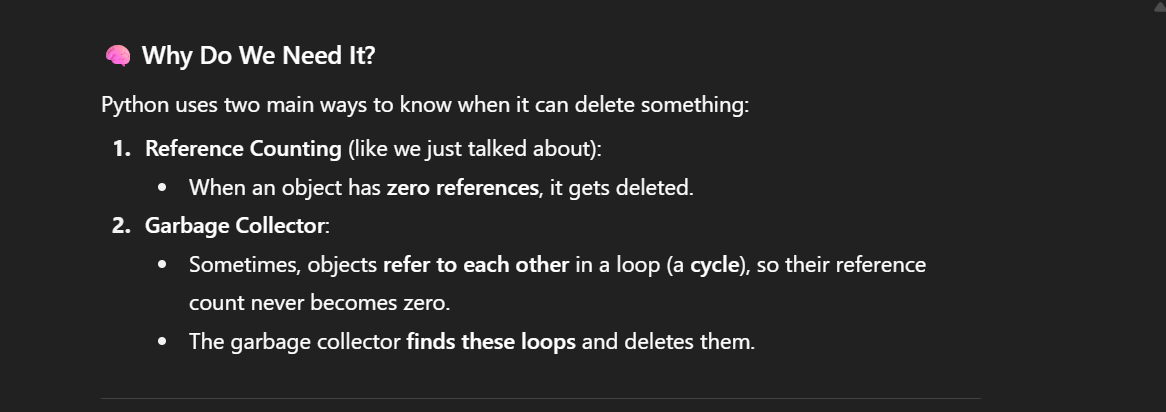

In [4]:
## Garbage collection
import gc 
# enable garbage collection
gc.enable


<function gc.enable()>

In [5]:
gc.disable()

In [7]:
gc.collect()

33

In [8]:
## get garbage collect statistci
print(gc.get_stats())

[{'collections': 202, 'collected': 1762, 'uncollectable': 0}, {'collections': 18, 'collected': 519, 'uncollectable': 0}, {'collections': 2, 'collected': 33, 'uncollectable': 0}]


In [9]:
## get unreachable objects
print(gc.garbage)

[]


## Memory mangement Best practices
Use local variable 
Avoid circular reference 
Use generators
Explicitly delete objects
profile memory usage


In [12]:
import gc 

class MyObject:
    def __init__(self,name):
        self.name=name
        print(f"Oject {self.name} created")
    
    def __del__(self):
        print(f"Object {self.name} deleted")
    
## create circular reference 
obj1=MyObject("obj1")
obj2=MyObject("obj2")

obj1.ref=obj2
obj2.ref=obj1

del obj1
del obj2

## Manuall trigger the garbage collection
gc.collect()


Oject obj1 created
Oject obj2 created
Object obj1 deleted
Object obj2 deleted
Object obj1 deleted
Object obj2 deleted


2810

In [14]:
## Generator for memory efficient

def generate_numbers(n):
    for i in range(n):
        yield i

## using the generator 
for num in generate_numbers(100000):
    print(num)
    if num>5:
        break



0
1
2
3
4
5
6


In [ ]:
## profiling memory usage with tracmalloc
import tracemalloc

def create_list():
    return [i for i in range(10000)]

def main():
    tracemalloc.start()

    create_list()

    snapshot=tracemalloc.take_snapshot()
    top_stats=snapshot.statistics('lineno')

    print("[Top 10 ]")
    for stat in top_stats[:10]:
        print(stat)
main()


[Top 10 ]
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\selectors.py:314: size=288 KiB, count=6, average=48.0 KiB
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\site-packages\IPython\core\compilerop.py:86: size=11.3 KiB, count=111, average=104 B
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\json\decoder.py:353: size=4140 B, count=35, average=118 B
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\site-packages\IPython\core\compilerop.py:174: size=3706 B, count=34, average=109 B
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\codeop.py:125: size=2650 B, count=28, average=95 B
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\site-packages\zmq\sugar\attrsettr.py:45: size=2200 B, count=40, average=55 B
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\threading.py:265: size=1520 B, count=4, average=380 B
c:\Users\Death Gravity\.conda\envs\hunter_env\Lib\site-packages\IPython\core\interactiveshell.py:1596: size=1520 B, count=1, average=1520 B
c:\Users\Death Gravity\.conda\envs

: 

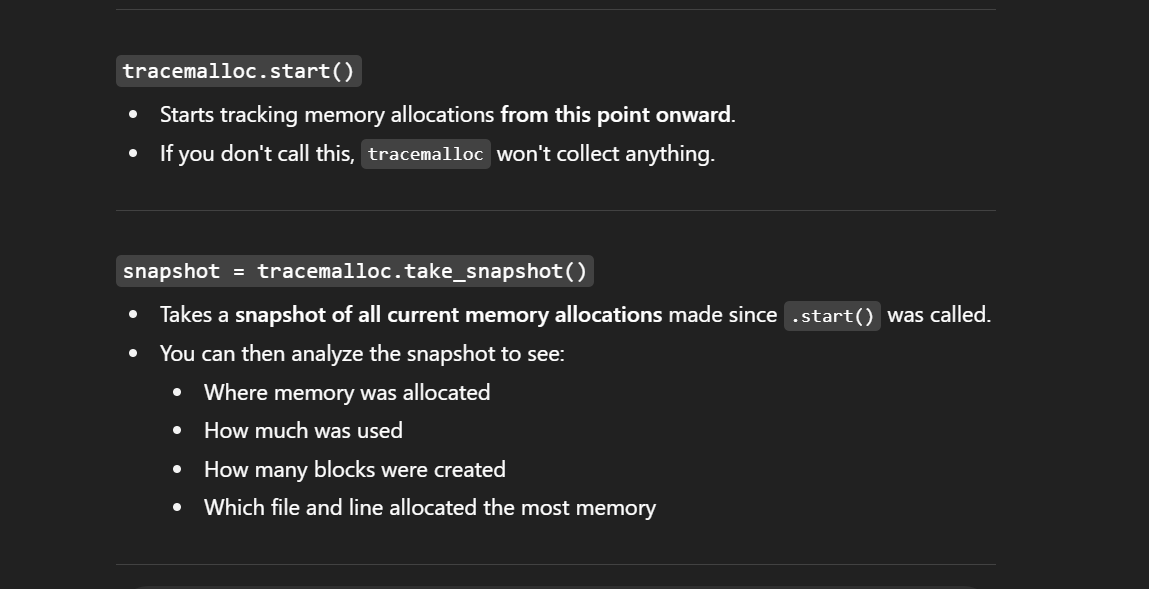

In [ ]:
# Import the tracemalloc module to trace memory allocations
import tracemalloc

# A simple function that creates a list of 10,000 numbers
def create_list():
    return [i for i in range(10000)]  # This line allocates memory by creating a large list

# Main function that performs memory tracking
def main():
    # Start tracing memory allocations from this point in the program
    tracemalloc.start()

    # Call the function that creates the list — this allocates memory
    create_list()

    # Take a snapshot of current memory allocations
    snapshot = tracemalloc.take_snapshot()

    # Get statistics grouped by (filename, line number)
    top_stats = snapshot.statistics('lineno')

    # Display the top 10 lines that consumed the most memory
    print("[Top 10 memory usage lines]")
    for stat in top_stats[:10]:
        # Print the memory usage for each line in a human-readable format
        # Example: file_path.py:line_number: size=... count=... average=...
        print(stat)

# This ensures the main function runs only when the script is executed directly
if __name__ == "__main__":
    main()
